In [3]:
# ======================================================
# LADDA MNIST
# ======================================================
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Ladda MNIST
mnist = fetch_openml('mnist_784', version=1)

# Data och labels
X = mnist.data.to_numpy()
y = mnist.target.astype(int)

# -----------------------------------
# Första split:
# Train + Validation / Test
# -----------------------------------

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -----------------------------------
# Andra split:
# Train / Validation
# -----------------------------------

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42
)

# -----------------------------------
# Storlekar
# -----------------------------------

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Training: (42000, 784)
Validation: (14000, 784)
Test: (14000, 784)


In [4]:
import tkinter as tk
from PIL import Image, ImageDraw
import os

# Create dataset folders
for i in range(10):
    os.makedirs(f"data/{i}", exist_ok=True)

class MNISTDrawer:
    def __init__(self, root):
        self.root = root
        self.root.title("MNIST Drawing App")

        self.canvas_size = 280  # large canvas for drawing
        self.image_size = 28    # MNIST size

        self.canvas = tk.Canvas(root, width=self.canvas_size, height=self.canvas_size, bg="black")
        self.canvas.pack()

        self.canvas.bind("<B1-Motion>", self.draw)

        self.button_frame = tk.Frame(root)
        self.button_frame.pack()

        for i in range(10):
            btn = tk.Button(self.button_frame, text=str(i), command=lambda i=i: self.save(i))
            btn.grid(row=0, column=i)

        self.clear_btn = tk.Button(root, text="Clear", command=self.clear)
        self.clear_btn.pack()

        # PIL image for saving
        self.image = Image.new("L", (self.canvas_size, self.canvas_size), 0)
        self.draw_image = ImageDraw.Draw(self.image)

    def draw(self, event):
        x, y = event.x, event.y
        r = 8

        self.canvas.create_oval(x-r, y-r, x+r, y+r, fill="white", outline="white")
        self.draw_image.ellipse([x-r, y-r, x+r, y+r], fill=255)

    def clear(self):
        self.canvas.delete("all")
        self.image = Image.new("L", (self.canvas_size, self.canvas_size), 0)
        self.draw_image = ImageDraw.Draw(self.image)

    def save(self, label):
        # Resize to MNIST size
        img = self.image.resize((self.image_size, self.image_size))

        # Save image
        count = len(os.listdir(f"data/{label}"))
        filename = f"data/{label}/{count}.png"
        img.save(filename)

        print(f"Saved {filename}")
        self.clear()

if __name__ == "__main__":
    root = tk.Tk()
    app = MNISTDrawer(root)
    root.mainloop()

In [5]:
# Pillow bibliotek
from PIL import Image

In [6]:
# CUSTOM PICS

import os

import numpy as np


data = []
labels = []

path = ".\data"

for label in range(10):
    folder = os.path.join(path, str(label))
    
    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)
        
        # Open image
        img = Image.open(img_path).convert('L')  # grayscale
        
        # Resize to 28x28
        img = img.resize((28, 28))
        
        # Convert to array
        img = np.array(img)
        
        # Invert colors (IMPORTANT for MNIST!)
        # img = 255 - img
        
        # Normalize
        img = img / 255.0
        
        data.append(img)
        labels.append(label)

# Convert to numpy
x_custom = np.array(data)
y_custom = np.array(labels)

print(x_custom.shape)  # (num_images, 28, 28)

(105, 28, 28)


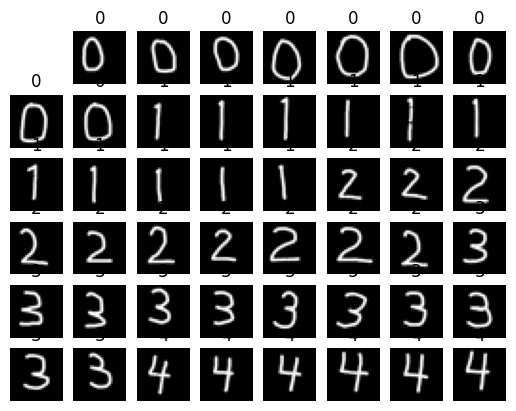

In [7]:
#Exempel egna bilder
import matplotlib.pyplot as plt

for i in range(1,48):
    plt.subplot(6, 8, i+1)
    plt.imshow(x_custom[i], cmap='gray')
    plt.title(y_custom[i])
    plt.axis('off')

plt.show()


In [8]:
#Formatet
#Normalisering

#Inga felaktiga

x_custom = x_custom / 255.0
y_custom = y_custom / 255.0

x_custom = x_custom.reshape(-1, 784)

y_custom = y_custom.astype(int)





In [9]:
# ======================================================
# LADDA MNIST + custom bilder
# ======================================================
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Ladda MNIST
mnist = fetch_openml('mnist_784', version=1)

# Data och labels
X = mnist.data.to_numpy()
y = mnist.target.astype(int)

x_custom = np.array(x_custom)
y_custom = np.array(y_custom)

# Combine
X_combine = np.concatenate((X, x_custom), axis=0)
y_combine = np.concatenate((y, y_custom), axis=0)







In [10]:
print(X_combine.shape)
print(y_combine.shape)
print()
print(y_combine.dtype)
print(np.unique(y_combine))

(70105, 784)
(70105,)

int64
[0 1 2 3 4 5 6 7 8 9]


In [11]:
# -----------------------------------
# Första split:
# Train + Validation / Test
# -----------------------------------

X_temp, X_test, y_temp, y_test = train_test_split(
    X_combine,
    y_combine,
    test_size=0.2,
    random_state=42
)

# -----------------------------------
# Andra split:
# Train / Validation
# -----------------------------------

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42
)

# -----------------------------------
# Storlekar
# -----------------------------------

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Training: (42063, 784)
Validation: (14021, 784)
Test: (14021, 784)


In [12]:
# Normalisera pixlar
X_train = X_train / 255.0
X_test = X_test / 255.0

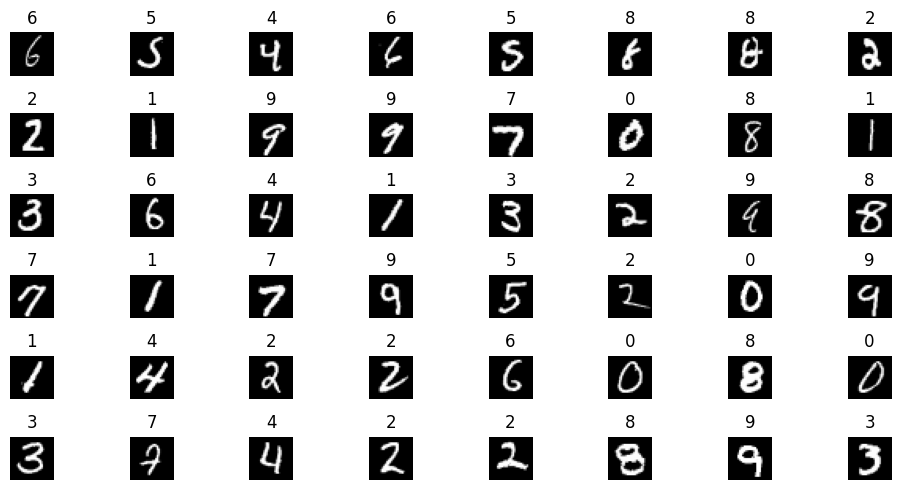

In [13]:
#plt.figure(figsize=(10,8))
plt.figure(figsize=(10,5))

for i in range(48):

    plt.subplot(6, 8, i+1)

    plt.imshow(
        X_train[i].reshape(28,28),
        cmap='gray'
    )

    plt.title(y_train[i])

    plt.axis('off')

plt.tight_layout()
plt.show()

In [14]:
#Linjär regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=300
)

In [15]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [16]:
y_pred = model.predict(X_test)

LogReg
Accuracy: 0.9181228157763355


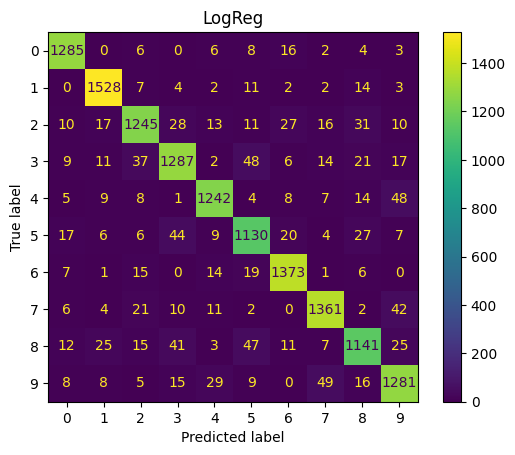

SVM
Accuracy: 0.9753227301904286


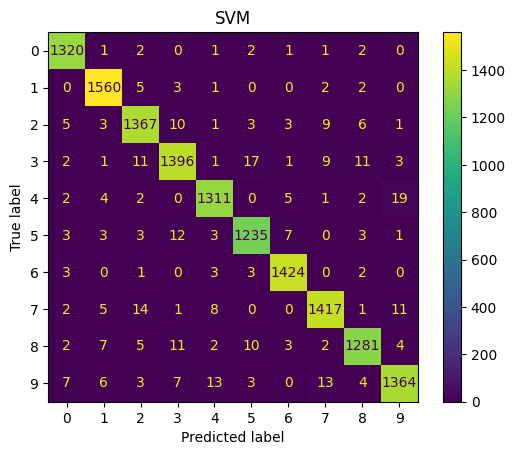

RF
Accuracy: 0.964695813422723


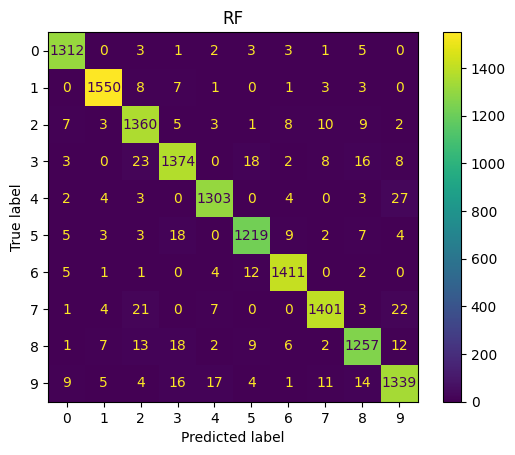

In [17]:
# Utvärdering flera modeller
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import *

# Modeller
logreg = LogisticRegression(max_iter=300)

svm = SVC()

rf = RandomForestClassifier()

# Träning
logreg.fit(X_train, y_train)
svm.fit(X_train, y_train)
rf.fit(X_train, y_train)

# Samling
models = {
    "LogReg": logreg,
    "SVM": svm,
    "RF": rf
}

# Utvärdering
for name, model in models.items():

    y_pred = model.predict(X_test)

    print(name)
    print("Accuracy:", accuracy_score(y_test, y_pred))

    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred)
    ).plot()

    plt.title(name)

    plt.show()

In [18]:
from sklearn.metrics import classification_report

models = {
    "LogReg": logreg,
    "SVM": svm,
    "RF": rf
}

for name, model in models.items():

    y_pred = model.predict(X_test)

    print("\n", name)

    print(classification_report(y_test, y_pred))


 LogReg
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1330
           1       0.95      0.97      0.96      1573
           2       0.91      0.88      0.90      1408
           3       0.90      0.89      0.89      1452
           4       0.93      0.92      0.93      1346
           5       0.88      0.89      0.88      1270
           6       0.94      0.96      0.95      1436
           7       0.93      0.93      0.93      1459
           8       0.89      0.86      0.88      1327
           9       0.89      0.90      0.90      1420

    accuracy                           0.92     14021
   macro avg       0.92      0.92      0.92     14021
weighted avg       0.92      0.92      0.92     14021


 SVM
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1330
           1       0.98      0.99      0.99      1573
           2       0.97      0.97      0.97      1408
         

In [19]:
#Logistic Regression - förbättringsmöjligheter

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

params = {
    "C": [0.1, 1, 10]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=2000),
    params,
    cv=3
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'C': 0.1}
0.9162922283241803


In [21]:
# SVM Support Vector MAchine. MYCKET TIDSKRÄVANDE!

from sklearn.svm import SVC

params = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"]
}

grid = GridSearchCV(
    SVC(),
    params,
    cv=3
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'C': 10, 'kernel': 'rbf'}
0.9781993676152437


In [22]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

params = {
    "n_estimators": [50, 100],
    "max_depth": [10, 20]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    params,
    cv=3
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 20, 'n_estimators': 100}
0.9607968998882628


In [1]:
import sys
print(sys.version)

3.11.15 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:12:15) [MSC v.1942 64 bit (AMD64)]


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt


Training with sgd
sgd - Epoch 1: 86.68%
sgd - Epoch 2: 89.57%
sgd - Epoch 3: 90.35%
sgd - Epoch 4: 91.03%
sgd - Epoch 5: 91.59%

Training with momentum
momentum - Epoch 1: 92.82%
momentum - Epoch 2: 94.34%
momentum - Epoch 3: 95.58%
momentum - Epoch 4: 96.07%
momentum - Epoch 5: 96.69%

Training with adam
adam - Epoch 1: 94.67%
adam - Epoch 2: 96.37%
adam - Epoch 3: 96.94%
adam - Epoch 4: 97.36%
adam - Epoch 5: 97.17%

Training with adamw
adamw - Epoch 1: 94.20%
adamw - Epoch 2: 96.20%
adamw - Epoch 3: 96.73%
adamw - Epoch 4: 96.97%
adamw - Epoch 5: 97.53%


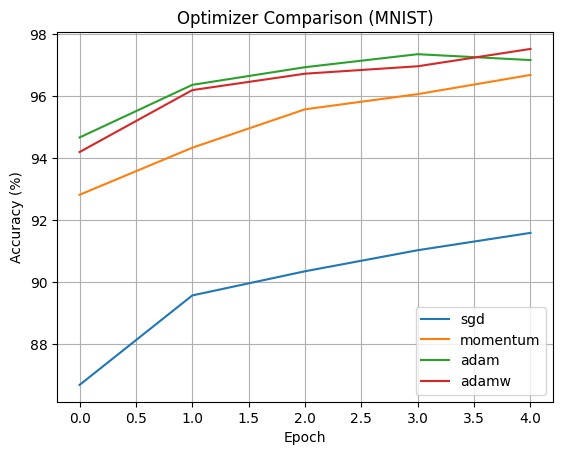

In [2]:
# ===== Data =====
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(root="./data", train=True, transform=transform, download=True)
test_dataset  = torchvision.datasets.MNIST(root="./data", train=False, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False)

# ===== Modell (MLP) =====
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)

# ===== Träning =====
def train_model(optimizer_name, epochs=5):
    model = MLP()
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=0.01)

    elif optimizer_name == "momentum":
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    elif optimizer_name == "adam":
        optimizer = optim.Adam(model.parameters(), lr=0.001)

    elif optimizer_name == "adamw":
        optimizer = optim.AdamW(model.parameters(), lr=0.001)

    acc_list = []

    for epoch in range(epochs):
        model.train()

        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # ===== Test accuracy =====
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in test_loader:
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        acc_list.append(accuracy)

        print(f"{optimizer_name} - Epoch {epoch+1}: {accuracy:.2f}%")

    return acc_list

# ===== Kör alla optimerare =====
optimizers = ["sgd", "momentum", "adam", "adamw"]
results = {}

for opt in optimizers:
    print(f"\nTraining with {opt}")
    results[opt] = train_model(opt, epochs=5)

# ===== Plot =====
plt.figure()

for opt in optimizers:
    plt.plot(results[opt], label=opt)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Optimizer Comparison (MNIST)")
plt.legend()
plt.grid()

plt.show()